In [1]:
from pyscripts.AutoEncoder_Experiment import *
import sys, jax, json
import jax.numpy as jnp
from datetime import datetime

import pyscripts.jax_amber3 as ja
import pyscripts.training_functions as tf

jax.config.update("jax_enable_x64", True)

In [2]:
json_fn = 'json_inputs/ACS_RPT.json'
with open(json_fn, 'r') as g:
        json_params = json.load(g)

In [3]:
#experiment = AutoEncoder_Experiment(json_fn)

In [ ]:
#ACS REPEAT RUN

num_init_epochs = json_params["training"]["epoch"]["num_init_epochs"]
struct_cutoff = json_params["training"]["epoch"]["struct_cutoff"]
scaling_cutoff = json_params["training"]["epoch"]["scaling_cutoff"]
final_cutoff = json_params["training"]["epoch"]["max_epoch"]

struct_thresh = json_params["training"]["thresh"]["structural_go_to_scaling"]
final_thresh = json_params["training"]["thresh"]["final_to_end"]

print(f"Epochs - Init: {num_init_epochs}, Struct: {struct_cutoff}, Scale: {scaling_cutoff}, Final {final_cutoff}")
print(f"Threshholds - Struct {struct_thresh}, Final {final_thresh}")

experiment = AutoEncoder_Experiment(json_fn)

print('##############################')
print('#####', f'Init {experiment.epoch:05d}', '#####')
print('##############################')
end_init_epoch = experiment.train_nepochs(tf.rmsd_rng_step, num_init_epochs,
                                          coefficients=[1,0], nan_check_ind=-4)
print('##############################')
print('#####', f'Strt {experiment.epoch:05d}', '#####')
print('##############################')
end_struct_epoch = experiment.train_to_threshold(tf.rmsd_rng_step, struct_thresh, struct_cutoff,
                                                 coefficients=[1,0], nan_check_ind=-4)
print('##############################')
print('#####', f'StSc {experiment.epoch:05d}', '#####')
print('##############################')
end_scaling_epoch = experiment.train_scaling_coef(training_functions.summation_rng_step, scaling_cutoff,
                                                  1, coefficients=[0,0], nan_check_ind=-1)
print('##############################')
print('#####', f'Scld {experiment.epoch:05d}', '#####')
print('##############################')
end_training_epoch = experiment.train_to_threshold(training_functions.summation_rng_step, final_thresh, final_cutoff,
                                                   coefficients=[0, 1], nan_check_ind=-1)
print('##############################')
print('#####', f'Done {experiment.epoch:05d}', '#####')
print('##############################')

Epochs - Init: 100, Struct: 1000, Scale: 5000, Final 10000
Threshholds - Struct 1.0, Final 1.0
(8000, 1926) (2000, 1926)
### MODEL TYPE = AE_Sigmoid_Dropout ###
######################################
#####     Initializing Done!     #####
AutoEncoder(
    # attributes
    input_size = 1926
    n_latents = 7
    hidden_layers = [1926, 1926, 1926]
    activators = [<jax._src.custom_derivatives.custom_jvp object at 0x7f7562e609d0>, <jax._src.custom_derivatives.custom_jvp object at 0x7f7562e609d0>, <jax._src.custom_derivatives.custom_jvp object at 0x7f7562e609d0>, <jax._src.custom_derivatives.custom_jvp object at 0x7f7562e609d0>]
    layer_ops = [<class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>]
    dropout_rates = [0.2, 0.2, 0.2]
)
######################################
##############################
##### Init 00000 #####
##############################
0 1.0060E+00 1.0060E+00 1.0049E+00 1.0049E+00 N

In [ ]:
#1 No RMTD, RMSD with new NN (Sigmoids) (Copy ACS Procedure, not NN)
json_fn = '1_RMSD_SigA.json'
with open(json_fn, 'r') as g:
        json_params = json.load(g)

num_init_epochs = json_params["training"]["epoch"]["num_init_epochs"]
struct_cutoff = json_params["training"]["epoch"]["struct_cutoff"]
scaling_cutoff = json_params["training"]["epoch"]["scaling_cutoff"]
final_cutoff = json_params["training"]["epoch"]["max_epoch"]

struct_thresh = json_params["training"]["thresh"]["structural_go_to_scaling"]
final_thresh = json_params["training"]["thresh"]["final_to_end"]

print(f"Epochs - Init: {num_init_epochs}, Struct: {struct_cutoff}, Scale: {scaling_cutoff}, Final {final_cutoff}")
print(f"Threshholds - Struct {struct_thresh}, Final {final_thresh}")

experiment = AutoEncoder_Experiment(json_fn)

print('##############################')
print('#####', f'Init {experiment.epoch:05d}', '#####')
print('##############################')
end_init_epoch = experiment.train_nepochs(tf.rmsd_rng_step, num_init_epochs,
                                          coefficients=[1,0], nan_check_ind=-4)
print('##############################')
print('#####', f'Strt {experiment.epoch:05d}', '#####')
print('##############################')
end_struct_epoch = experiment.train_to_threshold(tf.rmsd_rng_step, struct_thresh, struct_cutoff,
                                                 coefficients=[1,0], nan_check_ind=-4)
print('##############################')
print('#####', f'StSc {experiment.epoch:05d}', '#####')
print('##############################')
end_scaling_epoch = experiment.train_scaling_coef(training_functions.summation_rng_step, scaling_cutoff,
                                                  1, coefficients=[0,0], nan_check_ind=-1)
print('##############################')
print('#####', f'Scld {experiment.epoch:05d}', '#####')
print('##############################')
end_training_epoch = experiment.train_to_threshold(training_functions.summation_rng_step, final_thresh, final_cutoff,
                                                   coefficients=[0, 1], nan_check_ind=-1)
print('##############################')
print('#####', f'Done {experiment.epoch:05d}', '#####')
print('##############################')

In [4]:
#2 Structural Loss Function With ReLus, invoke the ACS json with main train
#json_fn = '2_Str_ReLu.json'
#with open(json_fn, 'r') as g:
#        json_params = json.load(g)

experiment = AutoEncoder_Experiment(json_fn)

experiment.run_main()

(8000, 1926) (2000, 1926)
### MODEL TYPE = AE_Sigmoid_Dropout ###
######################################
#####     Initializing Done!     #####
AutoEncoder(
    # attributes
    input_size = 1926
    n_latents = 4
    hidden_layers = [1926, 1926, 1926]
    activators = [<jax._src.custom_derivatives.custom_jvp object at 0x7fea1cc71790>, <jax._src.custom_derivatives.custom_jvp object at 0x7fea1cc71790>, <jax._src.custom_derivatives.custom_jvp object at 0x7fea1cc71790>, <jax._src.custom_derivatives.custom_jvp object at 0x7fea1cc71790>]
    layer_ops = [<class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>]
    dropout_rates = [0.2, 0.2, 0.2]
)
######################################
Main Invoked with the following params:
Epochs - Init: 100, Struct: 1000, Scale: 5000, Final 10000
Threshholds - Struct 1.0, Final 1.0
##############################
##### Init 00000 #####
##############################
0 NAN N

SystemExit: 69

/home/exouser/miniconda3/envs/jax_update/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3534: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
import jax.numpy as jnp

In [4]:
def tha_mean(function):


def my_test_func(a, a0, k):
    ener = 0.5*k*(a-a0)**2
    return ener

In [5]:
data, rest, = jnp.array((1.05, 2.3, 2.96)), jnp.array((1, 2, 3))

In [7]:
my_test_func(data, rest, 2).mean()

Array(0.03136666, dtype=float32)

Main Invoked with the following params:
Epochs - Init: 100, Struct: 1000, Scale: 5000, Final 10000
Threshholds - Struct 1.0, Final 1.0
##############################
##### Init 00000 #####
##############################


KeyboardInterrupt: 

In [5]:
rng_init = jax.random.PRNGKey(54)
rng, key = jax.random.split(rng_init)
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, experiment.test_data, rng)

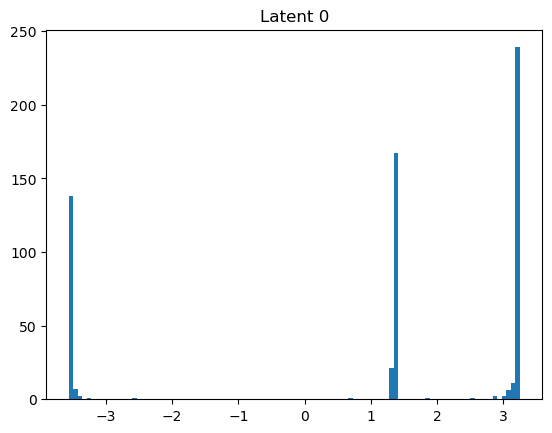

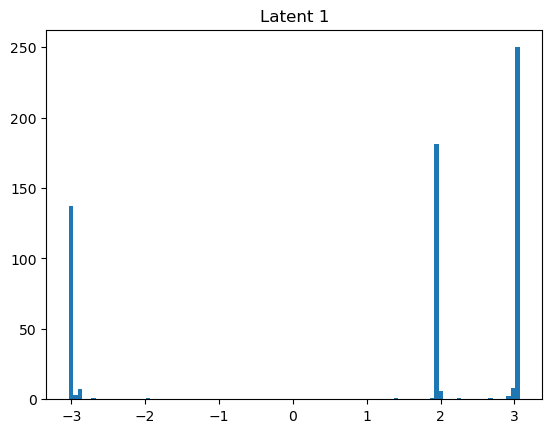

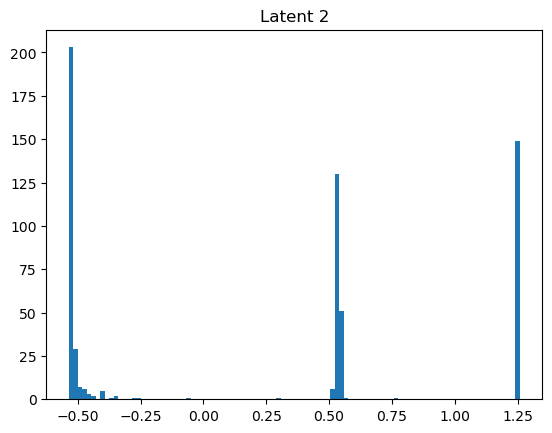

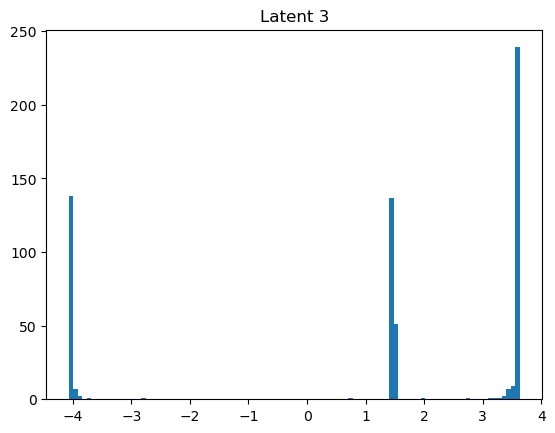

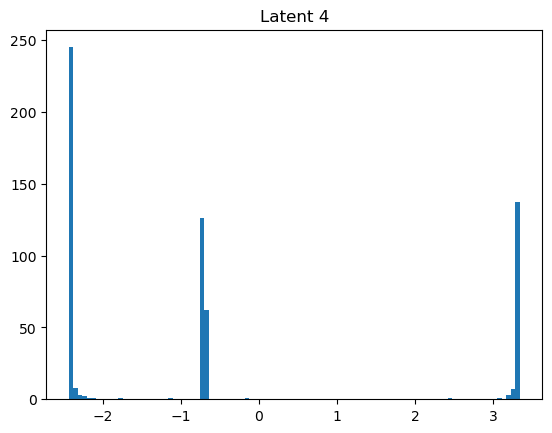

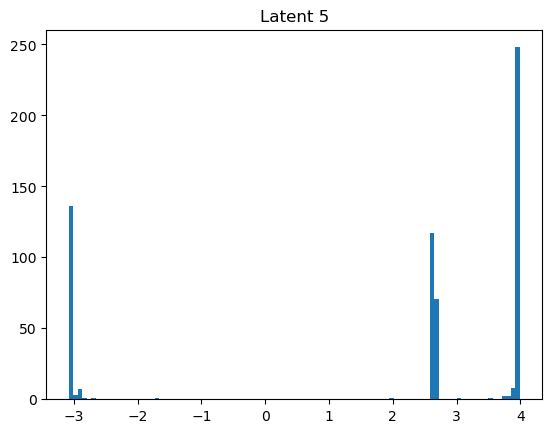

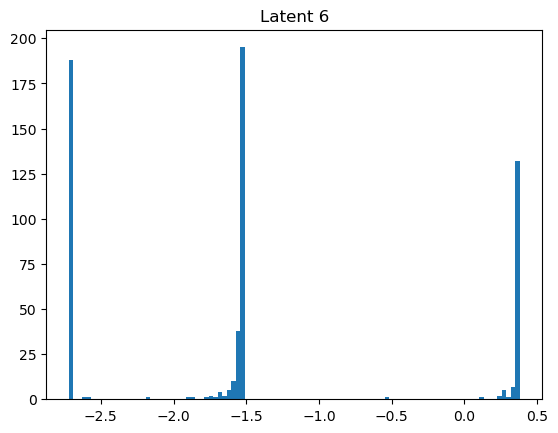

In [6]:
for i in range(latents.shape[-1]):
    plt.clf()
    plt.title(f'Latent {i}')
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [7]:
from sklearn.mixture import GaussianMixture

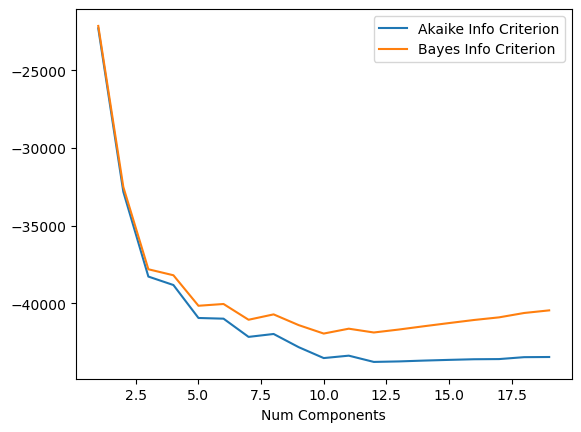

In [9]:
ics = []
for i in range(1, 20):
    X = np.array(latents)
    MM = GaussianMixture(n_components=i).fit(X)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()

In [21]:
X = np.array(latents)
MM = GaussianMixture(n_components=12).fit(X) #chosen based on above graph
samples = MM.sample(600)[0]

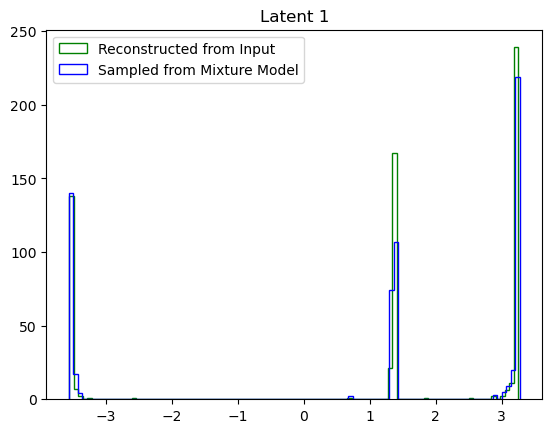

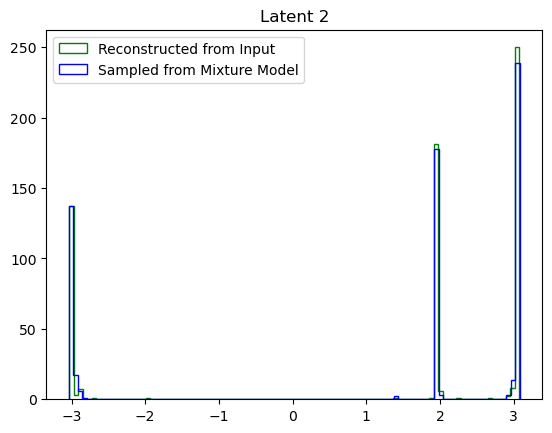

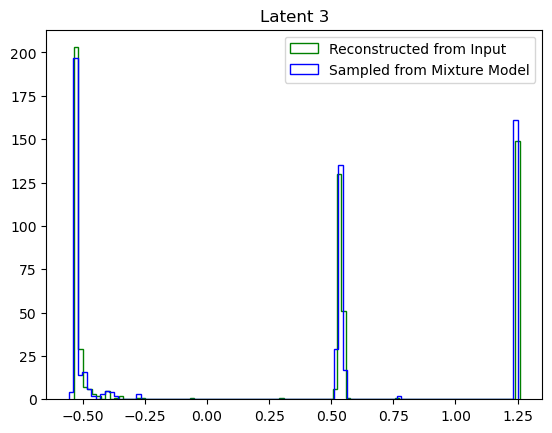

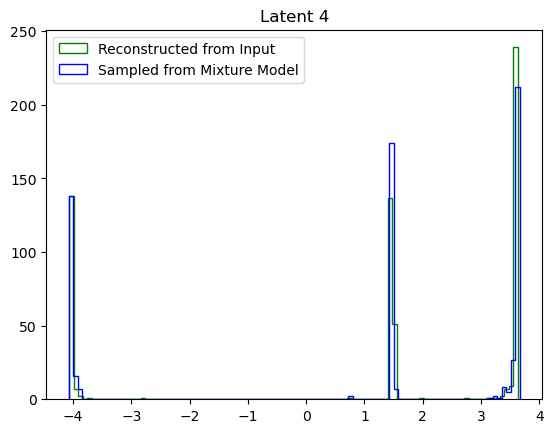

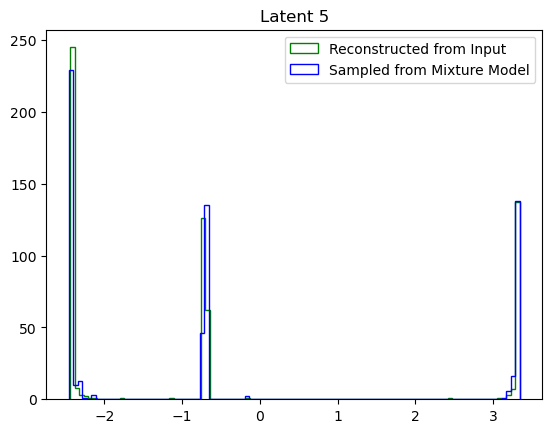

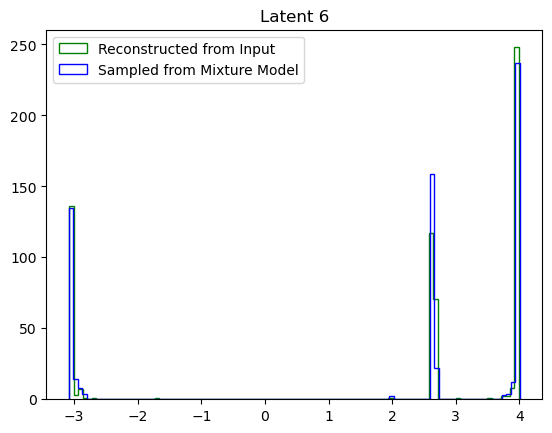

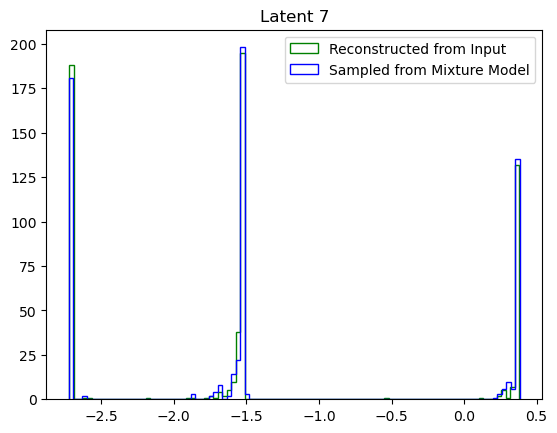

In [22]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:,i], bins=100, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=100, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

0 0 PearsonRResult(statistic=0.9999999999999999, pvalue=0.0)
0 1 PearsonRResult(statistic=0.9943699951097604, pvalue=0.0)
0 2 PearsonRResult(statistic=-0.9321147799437793, pvalue=5.867688030978148e-266)
0 3 PearsonRResult(statistic=0.9999864824374043, pvalue=0.0)
0 4 PearsonRResult(statistic=-0.999648444874008, pvalue=0.0)
0 5 PearsonRResult(statistic=0.9951981852362097, pvalue=0.0)
0 6 PearsonRResult(statistic=-0.7312599284329777, pvalue=1.9472672492183317e-101)
1 0 PearsonRResult(statistic=0.9943699951097604, pvalue=0.0)
1 1 PearsonRResult(statistic=1.0, pvalue=0.0)
1 2 PearsonRResult(statistic=-0.8884995723271369, pvalue=1.816316807665171e-204)
1 3 PearsonRResult(statistic=0.993846924839895, pvalue=0.0)
1 4 PearsonRResult(statistic=-0.9912301868836031, pvalue=0.0)
1 5 PearsonRResult(statistic=0.9999636895179892, pvalue=0.0)
1 6 PearsonRResult(statistic=-0.7994169774195382, pvalue=1.9080785147828316e-134)
2 0 PearsonRResult(statistic=-0.9321147799437793, pvalue=5.867688030978148e-266

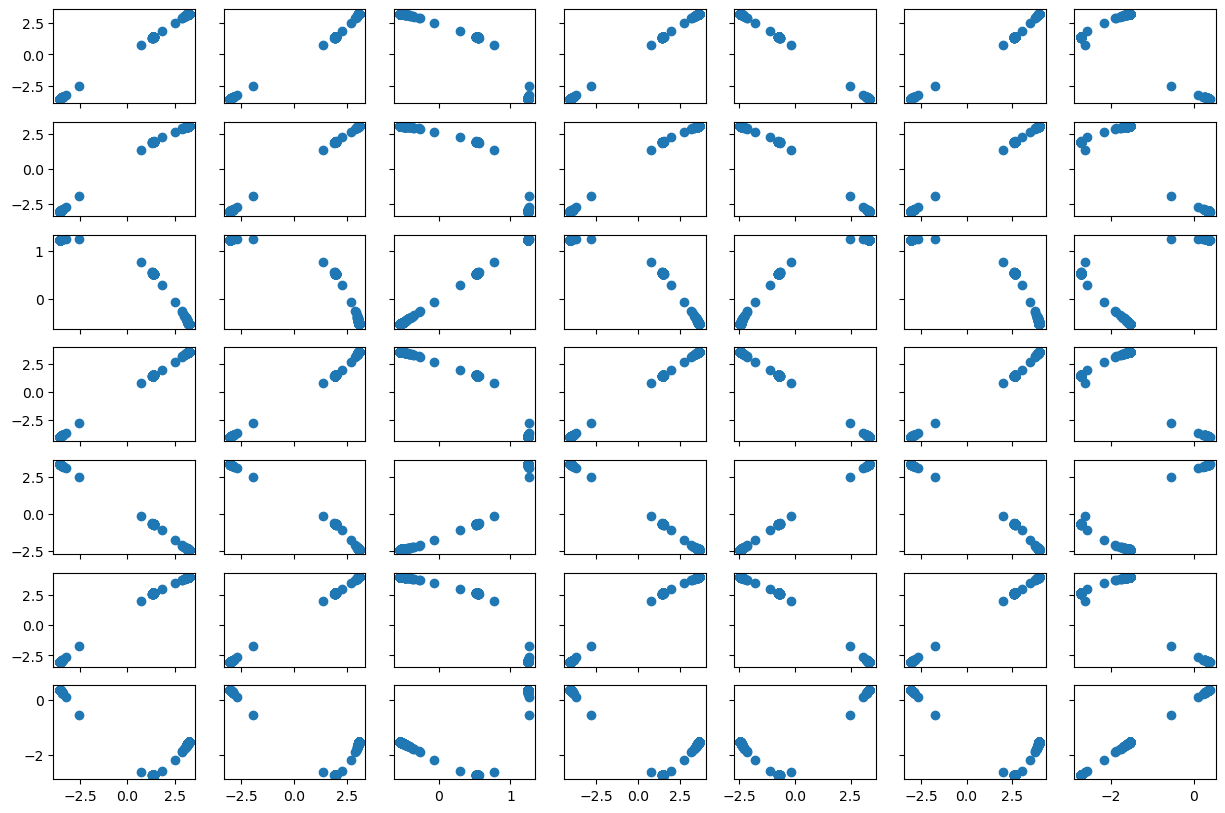

In [29]:
import scipy
n_L = latents.shape[-1]
fig, axs = plt.subplots(n_L, n_L, figsize=(15, 10), sharex='col', sharey='row')
for i in range(n_L):
    for j in range(n_L):
        axs[i,j].scatter(latents[:,j], latents[:,i])
        print(i, j, scipy.stats.pearsonr(latents[:,j], latents[:,i]))
fig.savefig('7L.png', dpi=600)

In [24]:
import jax_amber3 as ja
gas_fun, tors_fun = ja.get_amber_functions('Simulation/ala_deca_peptide.prmtop')

Excluding Outliers GMM - 2 RECON - 1


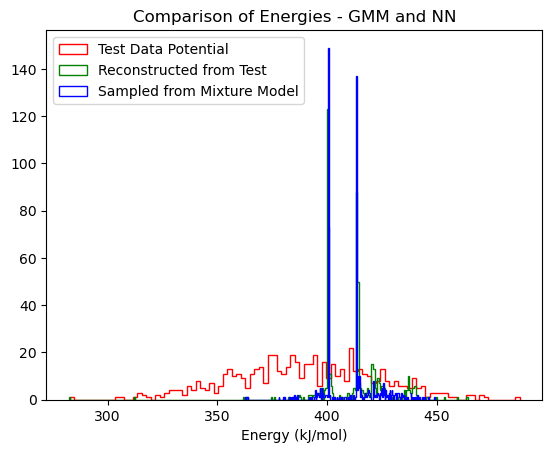

In [25]:
plt.clf()

recon_energies = gas_fun(recon)

decoded_samples = experiment.model.apply({'params': experiment.state.params}, samples, rng, method=experiment.model.decode)
sampled_energies = gas_fun(decoded_samples)

org_energies = gas_fun(experiment.test_data)

threshold = 1e3
num_excluded_gmm = len(sampled_energies) - len(sampled_energies[sampled_energies<threshold])
num_excluded_nn  = len(recon_energies) - len(recon_energies[recon_energies<threshold])
print(f'Excluding Outliers GMM - {num_excluded_gmm} RECON - {num_excluded_nn}')

_ = plt.hist(org_energies[org_energies < threshold], bins=100, histtype='step', color='r')
_ = plt.hist(recon_energies[recon_energies<threshold], bins=300, histtype='step', color='g')
_ = plt.hist(sampled_energies[sampled_energies<threshold], bins=300, histtype='step', color='b')

plt.legend(('Test Data Potential', 'Reconstructed from Test', 'Sampled from Mixture Model'))
plt.xlabel('Energy (kJ/mol)')
plt.title('Comparison of Energies - GMM and NN')
plt.show()

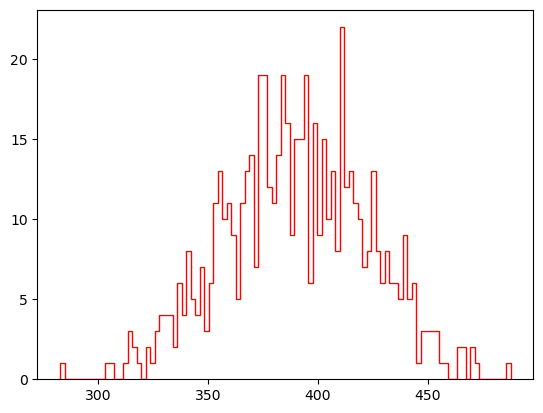

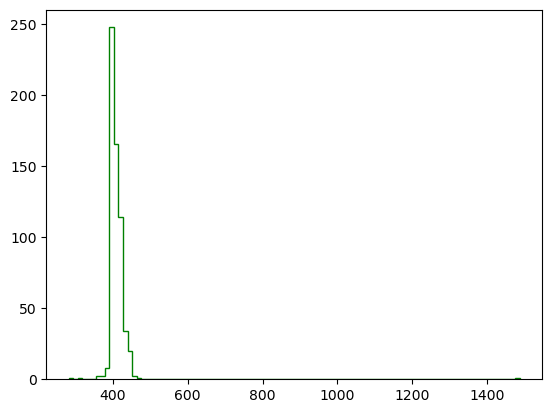

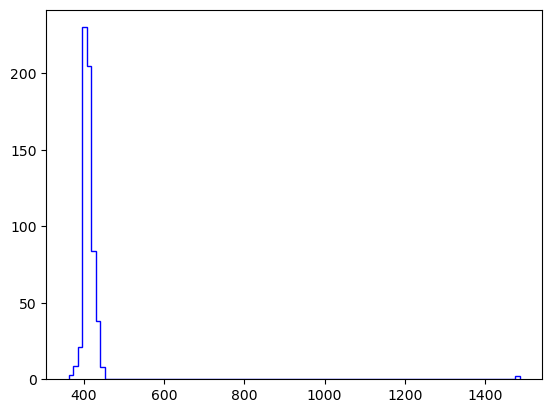

In [26]:
plt.clf()
_ = plt.hist(org_energies, bins=100, histtype='step', color='r')
plt.show()
plt.clf()
_ = plt.hist(recon_energies, bins=100, histtype='step', color='g')
plt.show()
plt.clf()
_ = plt.hist(sampled_energies, bins=100, histtype='step', color='b')
plt.show()

In [30]:
def write_traj(filename, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
        if traj_xyz.shape[-1] != 3:
            traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
        with md.formats.DCDTrajectoryFile(filename, 'w') as f:
            f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but saves it in angstrom

In [34]:
my_dict = {'DA_TestData.dcd' : experiment.test_data, 'DA_ReconData.dcd' : recon, 'DA_GMM.dcd' : decoded_samples}
for key, value in zip(my_dict.keys(), my_dict.values()):
    write_traj(key, value)